# Кластеризация точек продаж аптечной сети

Задача: разбить точки сети на сегменты, внутри которых точки похожи по трём независимым признакам:

1. **размер** - площадь торгового зала и «весовая категория» по деньгам (выручка и число чеков);
2. **ценовое позиционирование** - какую долю выручки точка делает в дешёвом, среднем и дорогом товаре своей
   подкатегории (пачки сравниваются только с пачками похожего объёма);
3. **ассортиментный профиль** - на какие категории товара точка «заточена».

Из трёх разбиений автоматически собирается итоговый сегмент с человекочитаемым названием. Дальше под каждый
сегмент строится своя ассортиментная матрица - это соседний проект
[`../Скоринг и выбор ассортиментной матрицы`](../Скоринг%20и%20выбор%20ассортиментной%20матрицы).

**Про данные.** В оригинале расчёт шёл по корпоративному DWH и был разнесён на 6 ноутбуков с ручным сведением
результатов в Excel. Здесь - один ноутбук на **синтетических данных** из общей базы
[`../synthetic_data`](../synthetic_data): справочник лекарств взят из открытого реестра ЖНВЛП (ГРЛС), точки,
чеки и остатки сгенерированы. Цифры не отражают реальный бизнес, но алгоритм, SQL-фильтры и логика
шагов - те же. Отличия от оригинальной методики перечислены в конце.

## Импорт библиотек и параметры

In [1]:
import os
import textwrap
import warnings

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.cluster.hierarchy as shc
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score, silhouette_score

pd.options.display.max_columns = 100
pd.options.display.float_format = '{:,.2f}'.format
sns.set_theme(style='whitegrid', font_scale=0.95)
plt.rcParams['figure.dpi'] = 110
warnings.filterwarnings('ignore', category=FutureWarning)  # предупреждения seaborn 0.12 о будущих версиях pandas
warnings.filterwarnings('ignore', message='Tight layout not applied')

In [2]:
# База с синтетическими данными (общая для проектов портфолио)
DB_PATH = os.environ.get('SYNTH_DB', '../synthetic_data/synthetic_projects.duckdb')

MIN_STORE_AGE_MONTHS = 6          # точка должна проработать не меньше полугода к концу периода
OPTICS_TRADE_POINT_TYPE_ID = 4    # формат «оптика» кластеризуется отдельно, здесь исключается
EXCLUDED_SALE_TYPES = ('Опт', 'Маркетплейс')  # не розница и заказы через сторонние агрегаторы
MIN_SHELF_LIFE_MONTHS = 6         # уценённый товар с коротким сроком годности искажает цены

PRICE_TIER_LOW_PERCENTILE = 30    # границы low / medium / high внутри группы сравнения
PRICE_TIER_HIGH_PERCENTILE = 70

# Категории фасовки для штучных форм (таблетки, капсулы, суппозитории, саше): пачка сравнивается по цене
# только с пачками похожего объёма своей подкатегории. Верхние границы интервалов, число доз в упаковке.
PACK_BINS = [(1, '1'), (4, '2-4'), (8, '5-8'), (12, '9-12'), (20, '13-20'), (30, '21-30'),
             (50, '31-50'), (100, '51-100'), (np.inf, '100+')]
MIN_PRICE_GROUP = 5               # группа меньше - объединяется с соседней категорией фасовки

# Диапазоны, в которых число кластеров выбирается автоматически («локоть» по ускорению расстояний Ward)
K_RANGE_SIZE = (3, 7)
K_RANGE_PRICE = (3, 7)
K_RANGE_ASSORT = (4, 10)

# Смежные категории, которые для ассортиментного анализа объединяются (как в оригинальном расчёте)
MERGE_CATEGORIES = {'Сердечно-сосудистая система': 'Сердце и кровь', 'Кровь и кроветворение': 'Сердце и кровь'}
# Категории с долей в выручке сети меньше порога объединяются в «Прочие препараты»: после стандартизации
# их случайный шум весил бы наравне с крупными категориями
MIN_CATEGORY_SHARE = 0.02

SEED = 2023

## Функции

In [3]:
con = duckdb.connect(DB_PATH)


def query(sql: str, params=None) -> pd.DataFrame:
    """SQL к базе с синтетикой. В оригинале здесь было чтение из корпоративного DWH через ODBC."""
    return con.execute(sql, params or []).df()


def choose_k(Z, k_min: int, k_max: int) -> int:
    """Автоматический выбор числа кластеров по «локтю» дендрограммы: берём k, при котором ускорение
    роста расстояния слияния (вторая разность) максимально. В оригинале тот же график смотрели глазами
    и число кластеров вписывали вручную."""
    last = Z[-(k_max + 1):, 2]
    acceleration = np.diff(last, 2)[::-1]           # индекс 0 соответствует k = 2
    ks = np.arange(2, 2 + len(acceleration))
    mask = (ks >= k_min) & (ks <= k_max)
    return int(ks[mask][np.argmax(acceleration[mask])])


K_DIAGNOSTICS = []   # показатели выбора числа кластеров по всем кластеризациям - для отчёта и сайта
K_PLOT_MAX = 10


def ward_clusters(X: pd.DataFrame, k_range, title: str, order_by: pd.Series = None, prefix: str = ''):
    """Иерархическая кластеризация Ward + автоматический выбор k по «локтю» + проверка силуэтом.
    Три графика: дендрограмма, цена склеивания и её ускорение, коэффициент силуэта для каждого k.
    Номера кластеров переупорядочиваются по среднему `order_by` (1 - наименьшее), чтобы номер что-то значил."""
    Z = shc.linkage(X, method='ward')
    k = choose_k(Z, *k_range)
    labels = shc.fcluster(Z, k, criterion='maxclust')

    ks = np.arange(2, K_PLOT_MAX + 1)
    merge_cost = np.array([Z[-(kk - 1), 2] for kk in ks])          # цена перехода от k к k-1 кластерам
    acceleration = np.diff(Z[-(K_PLOT_MAX + 1):, 2], 2)[::-1][:len(ks)]
    silhouette = np.array([silhouette_score(X, shc.fcluster(Z, kk, criterion='maxclust')) for kk in ks])
    for kk, c, a, sil in zip(ks, merge_cost, acceleration, silhouette):
        K_DIAGNOSTICS.append({'clustering': title, 'k': int(kk), 'merge_cost': c, 'acceleration': a,
                              'silhouette': sil, 'chosen': int(kk) == k, 'k_min': k_range[0], 'k_max': k_range[1]})

    fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
    shc.dendrogram(Z, truncate_mode='lastp', p=k, ax=axes[0], color_threshold=Z[-(k - 1), 2])
    axes[0].set_title(f'{title}: дендрограмма, {k} кластеров')
    axes[0].set_xlabel('размер кластера (число точек)')
    axes[1].bar(ks, merge_cost, color='#9aa5b1', label='цена склеивания k → k-1')
    axes[1].plot(ks, acceleration, color='#e76f51', marker='o', label='ускорение')
    axes[1].axvspan(k_range[0] - .5, k_range[1] + .5, color='#2a9d8f', alpha=.08, label='допустимый диапазон')
    axes[1].axvline(k, color='crimson', ls=':', lw=2)
    axes[1].set_title('«Локоть»: где склеивание резко дорожает'); axes[1].set_xlabel('число кластеров k'); axes[1].legend(fontsize=8)
    axes[2].plot(ks, silhouette, color='#264653', marker='o')
    axes[2].axvline(k, color='crimson', ls=':', lw=2)
    axes[2].set_title('Силуэт: чем выше, тем чётче разделены кластеры'); axes[2].set_xlabel('число кластеров k')
    plt.tight_layout(); plt.show()
    best_sil = int(ks[np.argmax(silhouette)])
    print(f'Выбрано k = {k} (локоть в диапазоне {k_range[0]}-{k_range[1]}); силуэт при k = {k}: {silhouette[k - 2]:.2f}, '
          f'максимум силуэта {silhouette.max():.2f} при k = {best_sil}')

    labels = pd.Series(labels, index=X.index)
    if order_by is not None:
        rank = order_by.groupby(labels).mean().rank(method='first').astype(int)
        labels = labels.map(rank)
    return labels.map(lambda c: f'{prefix}{c}')


def annotate_heatmap(ax, values, fmt):
    """Подписи ячеек тепловой карты (в seaborn 0.12 с matplotlib 3.8+ встроенные подписи выводятся только
    в первой строке, поэтому ставим их сами)."""
    vmax = np.nanmax(values) if np.size(values) else 1
    for (i, j), v in np.ndenumerate(values):
        if v == 0 or np.isnan(v):
            continue
        ax.text(j + .5, i + .5, format(int(v) if fmt == 'd' else v, fmt), ha='center', va='center', fontsize=9,
                color='white' if v > 0.6 * vmax else '#222')


def plot_crosstab(a: pd.Series, b: pd.Series, title: str, normalize=False, figsize=None, fmt='d'):
    """Тепловая карта пересечения двух разбиений: сколько точек в каждой паре кластеров."""
    ct = pd.crosstab(a, b, normalize='index' if normalize else False)
    if normalize:
        fmt = '.0%'
    figsize = figsize or (1.1 * ct.shape[1] + 3, 0.5 * ct.shape[0] + 1.6)
    plt.figure(figsize=figsize)
    ax = sns.heatmap(ct, cmap='YlGnBu', cbar=False, linewidths=.5)
    annotate_heatmap(ax, ct.to_numpy(dtype=float), fmt)
    plt.title(title); plt.xlabel(b.name); plt.ylabel(a.name)
    plt.xticks(rotation=30, ha='right'); plt.yticks(rotation=0)
    plt.tight_layout(); plt.show()

## 1. Отбор действующих точек

Закрытые точки и точки младше полугода (без представительной истории продаж) в кластеризацию не идут.
Формат «оптика» - отдельный тип точки со своим ассортиментом, его сегментируют отдельно.

In [4]:
period = query("SELECT MIN(Date) AS date_from, MAX(Date) AS date_to FROM pharmacy.cheques").iloc[0]
DATE_FROM, DATA_END = pd.Timestamp(period.date_from), pd.Timestamp(period.date_to)
# Кластеризация идёт только по первой половине периода (обучение): вторую половину проект скоринга
# использует как отложенную проверку матриц, её здесь не видно
TRAIN_DAYS = ((DATA_END - DATE_FROM).days + 1) // 2
DATE_TO = DATE_FROM + pd.Timedelta(days=TRAIN_DAYS - 1)

stores_all = query("""
    SELECT TradePointId, TradePointCode, BrandName, BusinessUnit, TradePointTypeId, TradePointType,
           TradeSquare, Layout, Location, OpenDate, CloseDate, IsVip, IsDiscounter, CurrentCategory
    FROM pharmacy.stores
""")
stores_all['age_months'] = (DATE_TO - stores_all['OpenDate']).dt.days / 30.44

is_open = stores_all['CloseDate'].isna() | (stores_all['CloseDate'] > DATE_TO)
is_mature = stores_all['age_months'] >= MIN_STORE_AGE_MONTHS
is_pharmacy = stores_all['TradePointTypeId'] != OPTICS_TRADE_POINT_TYPE_ID
stores = stores_all[is_open & is_mature & is_pharmacy].set_index('TradePointId')

print(f'Период расчёта: {DATE_FROM:%d.%m.%Y} - {DATE_TO:%d.%m.%Y} (дальше до {DATA_END:%d.%m.%Y} - отложенная проверка)')
print(f'Точек в справочнике: {len(stores_all)}; закрыты: {(~is_open).sum()}, младше {MIN_STORE_AGE_MONTHS} мес.: '
      f'{(is_open & ~is_mature).sum()}, оптика: {(is_open & is_mature & ~is_pharmacy).sum()}')
print(f'В кластеризацию идут: {len(stores)} аптек')

Период расчёта: 02.03.2026 - 29.03.2026 (дальше до 26.04.2026 - отложенная проверка)
Точек в справочнике: 260; закрыты: 13, младше 6 мес.: 7, оптика: 6
В кластеризацию идут: 234 аптек


## 2. Чеки с бизнес-фильтрами

Те же фильтры, что в оригинальном SQL к DWH: без опта и заказов через сторонние маркетплейсы, без уценённого
товара с остаточным сроком годности меньше 6 месяцев, без нетоварных позиций (пакеты, доставка). Ниже видно,
сколько строк отсекает каждый фильтр.

In [5]:
funnel = query(f"""
    SELECT
        COUNT(*)                                                             AS "все строки чеков",
        COUNT(*) FILTER (WHERE c.SaleType NOT IN {EXCLUDED_SALE_TYPES})      AS "без опта и маркетплейсов",
        COUNT(*) FILTER (WHERE c.SaleType NOT IN {EXCLUDED_SALE_TYPES}
                           AND c.ShelfLifeMonths >= {MIN_SHELF_LIFE_MONTHS}) AS "+ без уценки по сроку",
        COUNT(*) FILTER (WHERE c.SaleType NOT IN {EXCLUDED_SALE_TYPES}
                           AND c.ShelfLifeMonths >= {MIN_SHELF_LIFE_MONTHS}
                           AND p.product_class <> 'Нетоварные позиции')      AS "+ без нетоварных позиций"
    FROM pharmacy.cheques c
    JOIN pharmacy.products p USING (apCode)
    WHERE c.Date BETWEEN ? AND ?
""", [DATE_FROM, DATE_TO]).T.rename(columns={0: 'строк'})
funnel

,строк
все строки чеков,622433
без опта и маркетплейсов,591552
+ без уценки по сроку,573737
+ без нетоварных позиций,561744


In [6]:
df = query(f"""
    SELECT c.ChequeId, c.TradePointId, c.apCode, c.Date, c.Amount, c.Sum_Price, c.Sum_Fact, c.Sum_Purch,
           p.category, p.subcategory, p.doses_in_pack, p.pack_ambiguous, p.is_own_brand
    FROM pharmacy.cheques c
    JOIN pharmacy.products p USING (apCode)
    WHERE c.SaleType NOT IN {EXCLUDED_SALE_TYPES}
      AND c.ShelfLifeMonths >= {MIN_SHELF_LIFE_MONTHS}
      AND p.product_class <> 'Нетоварные позиции'
      AND c.Date BETWEEN ? AND ?
""", [DATE_FROM, DATE_TO])
df = df[df['TradePointId'].isin(stores.index)]
print(f'{len(df):,} строк, {df.ChequeId.nunique():,} чеков, {df.apCode.nunique():,} товаров, '
      f'{df.TradePointId.nunique()} точек')

536,152 строк, 288,389 чеков, 3,197 товаров, 234 точек


## 3. Размер точки

Два взгляда на размер: физический формат (площадь торгового зала) и «весовая категория» по деньгам
(выручка до скидок и число чеков). Их расхождение само по себе информативно: большая площадь со слабыми
продажами или маленькая точка с огромным трафиком - кандидаты на отдельное управленческое решение.

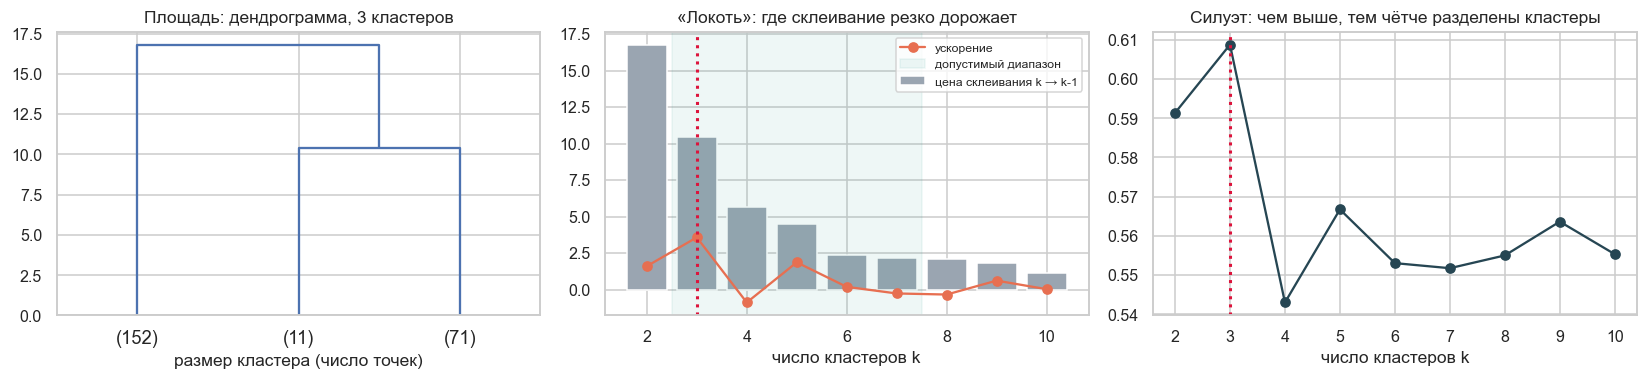

Выбрано k = 3 (локоть в диапазоне 3-7); силуэт при k = 3: 0.61, максимум силуэта 0.61 при k = 3


In [7]:
size = df.groupby('TradePointId').agg(Revenue=('Sum_Price', 'sum'), ChequeCount=('ChequeId', 'nunique'))
size = size.join(stores[['TradeSquare']])
size['mean_purch'] = size.Revenue / size.ChequeCount

X_square = pd.DataFrame(StandardScaler().fit_transform(size[['TradeSquare']]), index=size.index)
size['ID_size_square'] = ward_clusters(X_square, K_RANGE_SIZE, 'Площадь', order_by=size.TradeSquare, prefix='П')

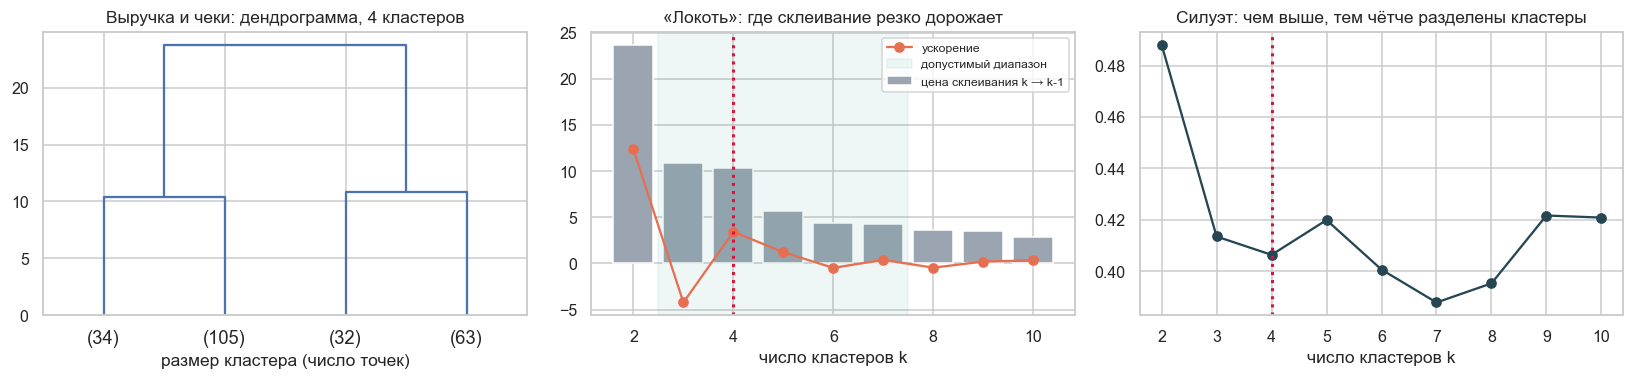

Выбрано k = 4 (локоть в диапазоне 3-7); силуэт при k = 4: 0.41, максимум силуэта 0.49 при k = 2


In [8]:
# выручка и чеки сильно скошены вправо - кластеризуем в логарифмах (в оригинале - без логарифма)
X_money = pd.DataFrame(StandardScaler().fit_transform(np.log(size[['Revenue', 'ChequeCount']])), index=size.index)
size['ID_size_rev_cheque'] = ward_clusters(X_money, K_RANGE_SIZE, 'Выручка и чеки',
                                           order_by=size.Revenue, prefix='В')

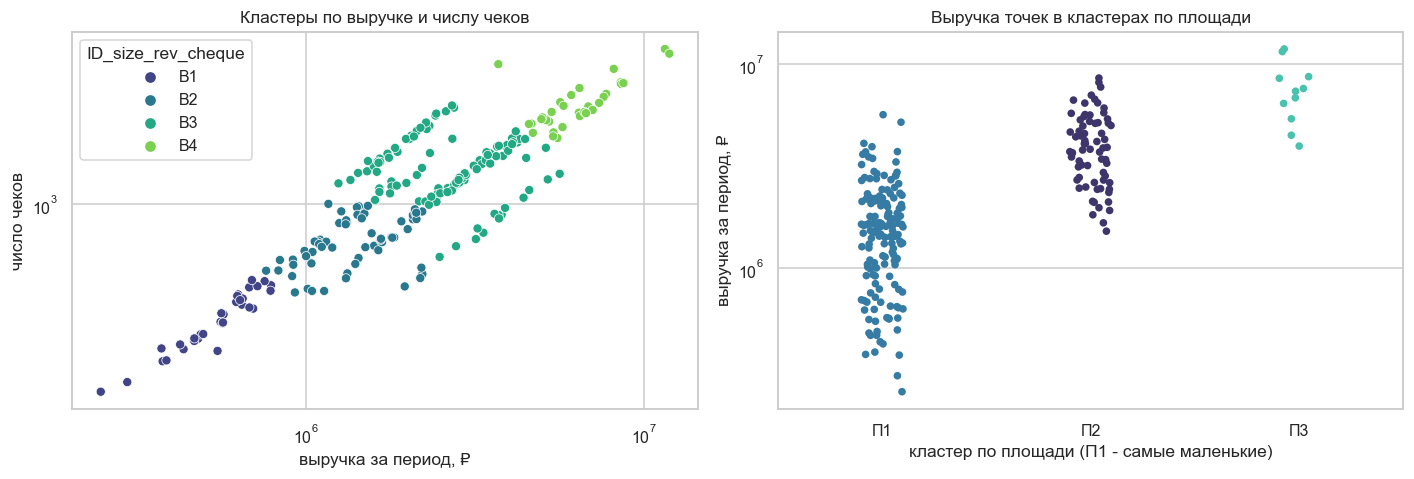

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.scatterplot(data=size, x='Revenue', y='ChequeCount', hue='ID_size_rev_cheque',
                hue_order=sorted(size.ID_size_rev_cheque.unique()), palette='viridis', ax=axes[0])
axes[0].set(xscale='log', yscale='log', title='Кластеры по выручке и числу чеков', xlabel='выручка за период, ₽',
            ylabel='число чеков')
sns.stripplot(data=size, x='ID_size_square', y='Revenue', order=sorted(size.ID_size_square.unique()),
              hue='ID_size_square', palette='mako', legend=False, size=5, ax=axes[1])
axes[1].set(yscale='log', title='Выручка точек в кластерах по площади', xlabel='кластер по площади (П1 - самые маленькие)',
            ylabel='выручка за период, ₽')
plt.tight_layout(); plt.show()

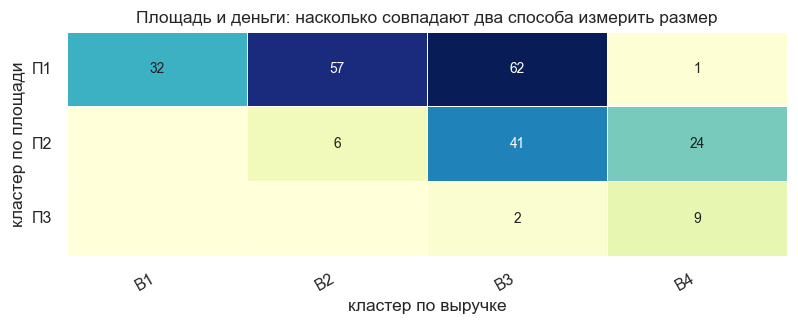

In [10]:
plot_crosstab(size.ID_size_square.rename('кластер по площади'), size.ID_size_rev_cheque.rename('кластер по выручке'),
              'Площадь и деньги: насколько совпадают два способа измерить размер')

## 4. Ценовое позиционирование

Идея в два шага:

1. **Разметить товары по ценовым уровням** `low` / `medium` / `high` внутри своей подкатегории - по 30-му и
   70-му перцентилю цены. «Дорого» и «дёшево» относительны: 500 ₽ за противовирусное и за пластырь - разные истории.
2. **Описать точку долями выручки** в каждом уровне и кластеризовать точки по этому профилю.

Покупатель платит за пачку, поэтому сравнивается **цена пачки** - но только с пачками похожего объёма:
иначе упаковка на 100 таблеток всегда выглядела бы «дорогой», а упаковка на 10 - «дешёвой». Штучные формы
(таблетки, капсулы, суппозитории, саше) делятся на категории фасовки по числу доз (1, 2-4, 5-8, 9-12, 13-20,
21-30, 31-50, 51-100, 100+), и уровни считаются внутри «подкатегория × категория фасовки». Если в такой группе
меньше 5 товаров, перцентили бессмысленны - группа объединяется с соседней категорией фасовки. Нештучные формы
(сиропы, мази, растворы, нелекарственный ассортимент) сравниваются по цене упаковки внутри подкатегории.

Позиции с неоднозначной фасовкой (наборы, комплекты) и товары собственной торговой марки (у СТМ своя модель
ценообразования, она сдвигала бы перцентили) исключаются.

In [11]:
# средняя цена упаковки: в приоритете остатки (устойчивее к разовым акциям), чеки - запасной источник
stock = query("""
    SELECT s.apCode, SUM(s.Sum_Purch) / SUM(s.Amount) AS mean_package
    FROM pharmacy.stock s
    GROUP BY s.apCode
""").set_index('apCode')['mean_package']
cheque_sum = df.groupby('apCode')[['Sum_Purch', 'Amount']].sum()
cheque_price = cheque_sum.Sum_Purch / cheque_sum.Amount

products = query("""
    SELECT apCode, name, category, subcategory, form_group, doses_in_pack, pack_ambiguous, is_own_brand
    FROM pharmacy.products WHERE product_class <> 'Нетоварные позиции'
""").set_index('apCode')
price = products[~products.pack_ambiguous & ~products.is_own_brand].copy()
price['mean_package'] = stock.reindex(price.index).fillna(cheque_price.reindex(price.index))
price = price.dropna(subset=['mean_package'])
print(f'Цена есть у {len(price):,} товаров; из них {price.doses_in_pack.notna().sum():,} - штучные формы')

Цена есть у 2,976 товаров; из них 2,239 - штучные формы


In [12]:
def pack_bin(doses):
    """Категория фасовки по числу доз; у нештучных форм категория одна."""
    if pd.isna(doses):
        return 'нештучные'
    return next(label for upper, label in PACK_BINS if doses <= upper)


def merge_small_bins(sub: pd.DataFrame) -> pd.Series:
    """Внутри подкатегории объединяет категории фасовки, где меньше MIN_PRICE_GROUP товаров, с соседней
    (с той из соседних, где товаров меньше). Возвращает итоговую группу сравнения для каждого товара."""
    order = [label for _, label in PACK_BINS]
    groups = [[b] for b in order if (sub.pack_bin == b).any()]
    size = lambda g: sub.pack_bin.isin(g).sum()
    while len(groups) > 1 and min(size(g) for g in groups) < MIN_PRICE_GROUP:
        i = min(range(len(groups)), key=lambda j: size(groups[j]))
        neighbours = [j for j in (i - 1, i + 1) if 0 <= j < len(groups)]
        j = min(neighbours, key=lambda n: size(groups[n]))
        a, b = sorted((i, j))
        groups[a:b + 1] = [groups[a] + groups[b]]
    def label(g):
        low = g[0].split('-')[0].rstrip('+')
        if g[-1] == '100+':
            return low + '+'
        return g[0] if len(g) == 1 else low + '-' + g[-1].split('-')[-1]
    name = {b: label(g) for g in groups for b in g}
    return sub.pack_bin.map(name)


price['pack_bin'] = price.doses_in_pack.map(pack_bin)
countable = price.pack_bin != 'нештучные'
price['pack_group'] = 'нештучные'
price.loc[countable, 'pack_group'] = price[countable].groupby('subcategory', group_keys=False).apply(merge_small_bins)
price['price_group'] = price.subcategory + ' | ' + price.pack_group

groups = price.groupby('price_group').size()
print(f'Групп сравнения «подкатегория × фасовка»: {len(groups)}; меньше {MIN_PRICE_GROUP} товаров осталось в '
      f'{(groups < MIN_PRICE_GROUP).sum()} (подкатегории, где товаров мало всего)')
price.pack_group.value_counts().rename('товаров').to_frame().T

Групп сравнения «подкатегория × фасовка»: 194; меньше 5 товаров осталось в 32 (подкатегории, где товаров мало всего)


pack_group,нештучные,21-30,51-100,13-20,51+,31-50,9-12,5-12,13-30,31-100,5-8,9-20,21-100,5-20,100+,5-30,9-100,9-50,2-4,1-8,21-50,1-100,1-12,13-50,2-12,9-30
товаров,737,553,392,270,203,203,104,76,60,55,42,39,38,35,34,20,20,19,16,14,11,11,10,8,4,2


In [13]:
pct = price.groupby('price_group').agg(
    percentile_low=('mean_package', lambda x: np.percentile(x, PRICE_TIER_LOW_PERCENTILE)),
    percentile_high=('mean_package', lambda x: np.percentile(x, PRICE_TIER_HIGH_PERCENTILE)),
)
price = price.join(pct, on='price_group')
price['price_tier'] = np.select([price.mean_package < price.percentile_low,
                                 price.mean_package <= price.percentile_high], ['low', 'medium'], 'high')

# Бизнес-правила оригинального расчёта - на уровне подкатегории, по цене упаковки:
# 1) разброс цен в подкатегории меньше 20% - делить на уровни бессмысленно, подкатегория исключается;
# 2) подкатегория в целом дешёвая - весь её товар считается low.
sub = price.groupby('subcategory').mean_package.quantile([PRICE_TIER_LOW_PERCENTILE / 100, PRICE_TIER_HIGH_PERCENTILE / 100]).unstack()
sub.columns = ['nominal_low', 'nominal_high']
nominal_ratio = sub.nominal_high / sub.nominal_low - 1
too_narrow = nominal_ratio[nominal_ratio < 0.2].index
force_low = sub[(sub.nominal_high < 100) | ((sub.nominal_high < 150) & (nominal_ratio < 1))].index
price = price[~price.subcategory.isin(too_narrow)]
price.loc[price.subcategory.isin(force_low), 'price_tier'] = 'low'
print(f'Подкатегорий: {len(sub)}; исключено как слишком узкие: {len(too_narrow)}; целиком low: {len(force_low)}')
price.price_tier.value_counts(normalize=True).rename('доля товаров').to_frame()

Подкатегорий: 81; исключено как слишком узкие: 9; целиком low: 8


,доля товаров
price_tier,
medium,0.38
low,0.32
high,0.31


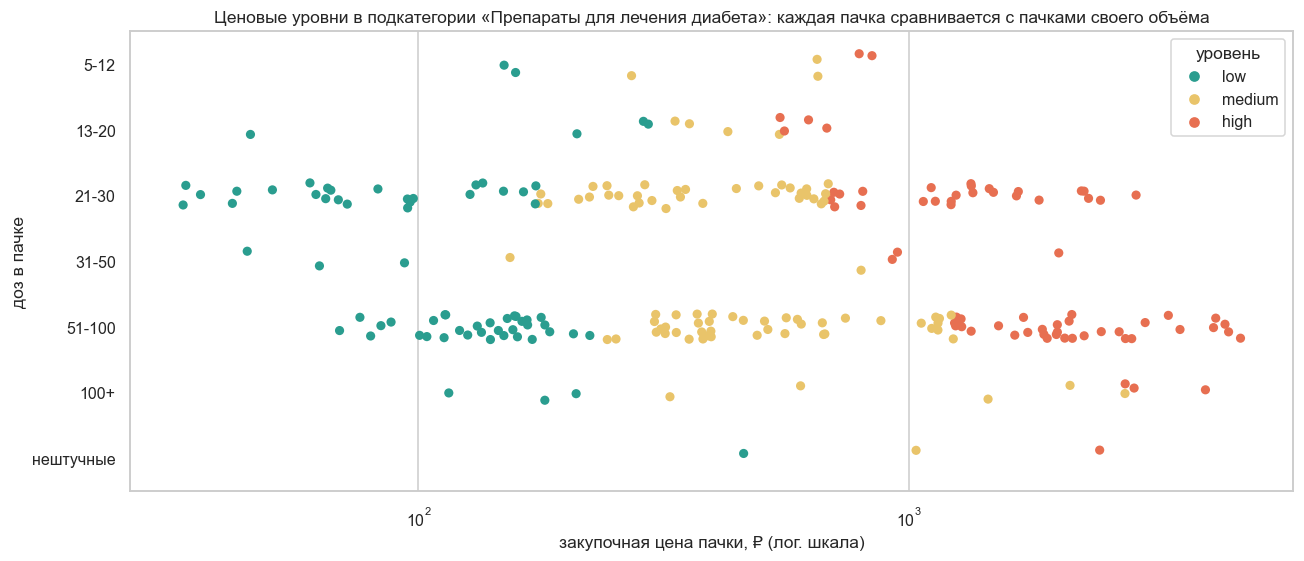

In [14]:
# пример разметки: одна подкатегория - пачки сравниваются внутри своей категории фасовки
example = price[price.pack_group != 'нештучные'].subcategory.value_counts().index[0]
ex = price[price.subcategory == example]
order = sorted(ex.pack_group.unique(), key=lambda g: float(g.split('-')[0].rstrip('+')) if g[0].isdigit() else 1e9)
plt.figure(figsize=(12, 0.55 * len(order) + 1.4))
sns.stripplot(data=ex, x='mean_package', y='pack_group', order=order, hue='price_tier', hue_order=['low', 'medium', 'high'],
              palette={'low': '#2a9d8f', 'medium': '#e9c46a', 'high': '#e76f51'}, size=6, jitter=0.2)
plt.xscale('log'); plt.xlabel('закупочная цена пачки, ₽ (лог. шкала)'); plt.ylabel('доз в пачке')
plt.title(f'Ценовые уровни в подкатегории «{example}»: каждая пачка сравнивается с пачками своего объёма')
plt.legend(title='уровень'); plt.tight_layout(); plt.show()

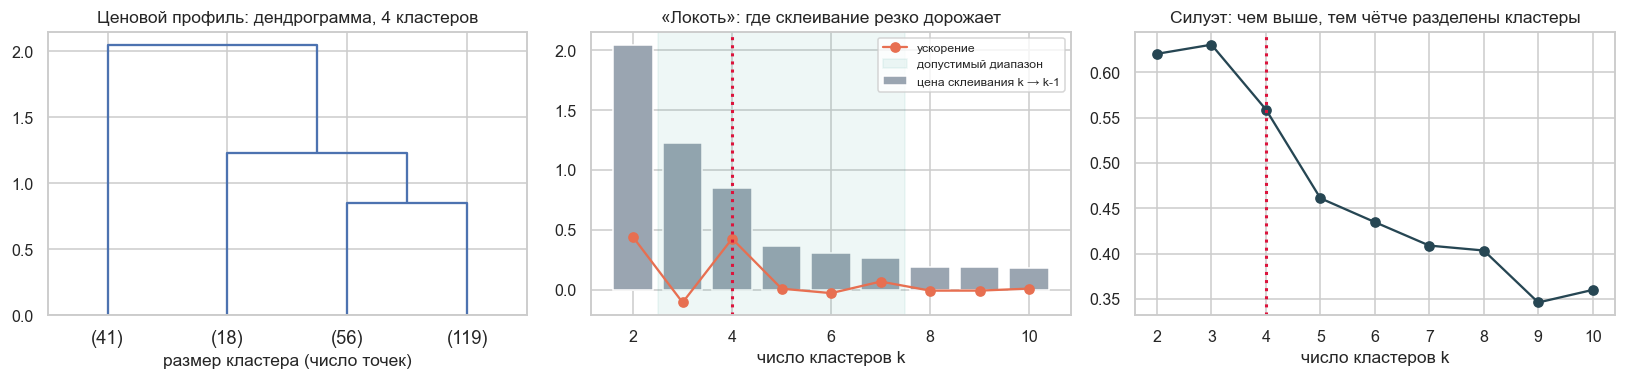

Выбрано k = 4 (локоть в диапазоне 3-7); силуэт при k = 4: 0.56, максимум силуэта 0.63 при k = 3


In [15]:
sales_tier = df.merge(price[['price_tier']], left_on='apCode', right_index=True)
price_profile = sales_tier.pivot_table(index='TradePointId', columns='price_tier', values='Sum_Purch',
                                       aggfunc='sum', fill_value=0)[['low', 'medium', 'high']]
price_profile = price_profile.div(price_profile.sum(axis=1), axis=0)
price_index = price_profile.high - price_profile.low      # >0 - точка смещена в дорогой товар

price_profile['ID_prices'] = ward_clusters(price_profile[['low', 'medium', 'high']], K_RANGE_PRICE, 'Ценовой профиль',
                                           order_by=price_index, prefix='Ц')

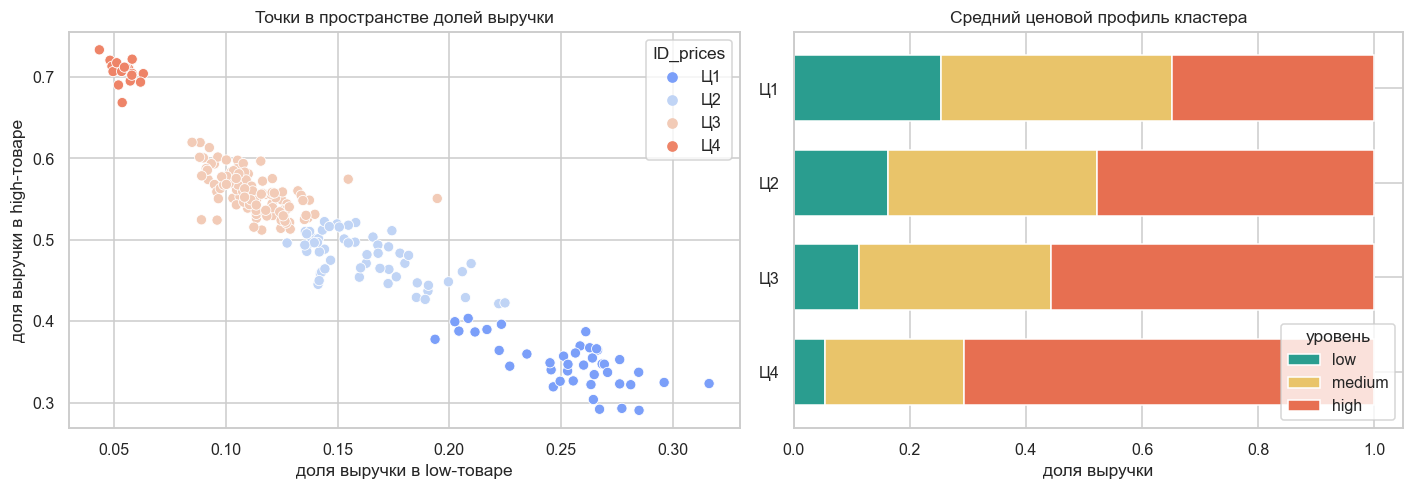

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), gridspec_kw={'width_ratios': [1.1, 1]})
sns.scatterplot(data=price_profile, x='low', y='high', hue='ID_prices', palette='coolwarm',
                hue_order=sorted(price_profile.ID_prices.unique()), s=45, ax=axes[0])
axes[0].set(title='Точки в пространстве долей выручки', xlabel='доля выручки в low-товаре',
            ylabel='доля выручки в high-товаре')
means = price_profile.groupby('ID_prices')[['low', 'medium', 'high']].mean()
means.plot.barh(stacked=True, color=['#2a9d8f', '#e9c46a', '#e76f51'], ax=axes[1], width=0.7)
axes[1].set(title='Средний ценовой профиль кластера', xlabel='доля выручки', ylabel='')
axes[1].legend(title='уровень', loc='lower right'); axes[1].invert_yaxis()
plt.tight_layout(); plt.show()

## 5. Ассортиментный профиль

Точка описывается вектором долей категорий в её собственной выручке - это «на что точка заточена», независимо
от её размера. Вектор стандартизуется и кластеризуется целиком (финальный вариант оригинального расчёта; перед
ним пробовались поочерёдные разбиения по каждой категории отдельно).

Объединены в «Прочие препараты»: Гормоны системного действия, Дерматология, Иммуномодуляторы и онкология, Оптика, Органы чувств, Прочие препараты


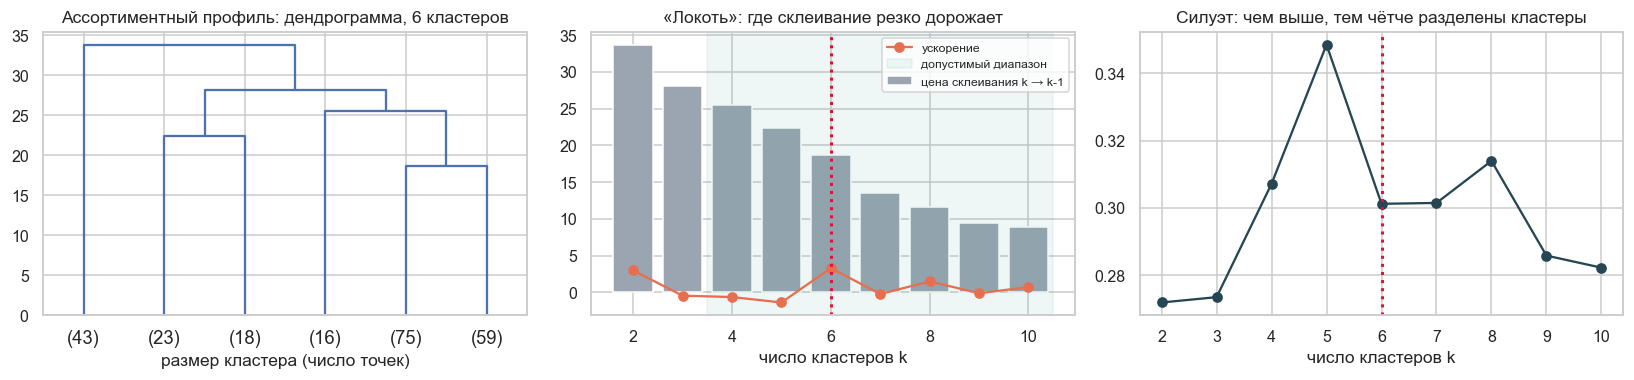

Выбрано k = 6 (локоть в диапазоне 4-10); силуэт при k = 6: 0.30, максимум силуэта 0.35 при k = 5


In [17]:
df['category_group'] = df.category.replace(MERGE_CATEGORIES)
share = df.groupby('category_group').Sum_Price.sum() / df.Sum_Price.sum()
small = share[share < MIN_CATEGORY_SHARE].index
df.loc[df.category_group.isin(small), 'category_group'] = 'Прочие препараты'
print('Объединены в «Прочие препараты»:', ', '.join(small))
assort = df.pivot_table(index='TradePointId', columns='category_group', values='Sum_Price', aggfunc='sum', fill_value=0)
assort = assort.div(assort.sum(axis=1), axis=0)
X_assort = pd.DataFrame(StandardScaler().fit_transform(assort), index=assort.index, columns=assort.columns)
ID_groups = ward_clusters(X_assort, K_RANGE_ASSORT, 'Ассортиментный профиль', prefix='А')
ID_groups = ID_groups.map(lambda c: f'А{int(c[1:]):02d}')

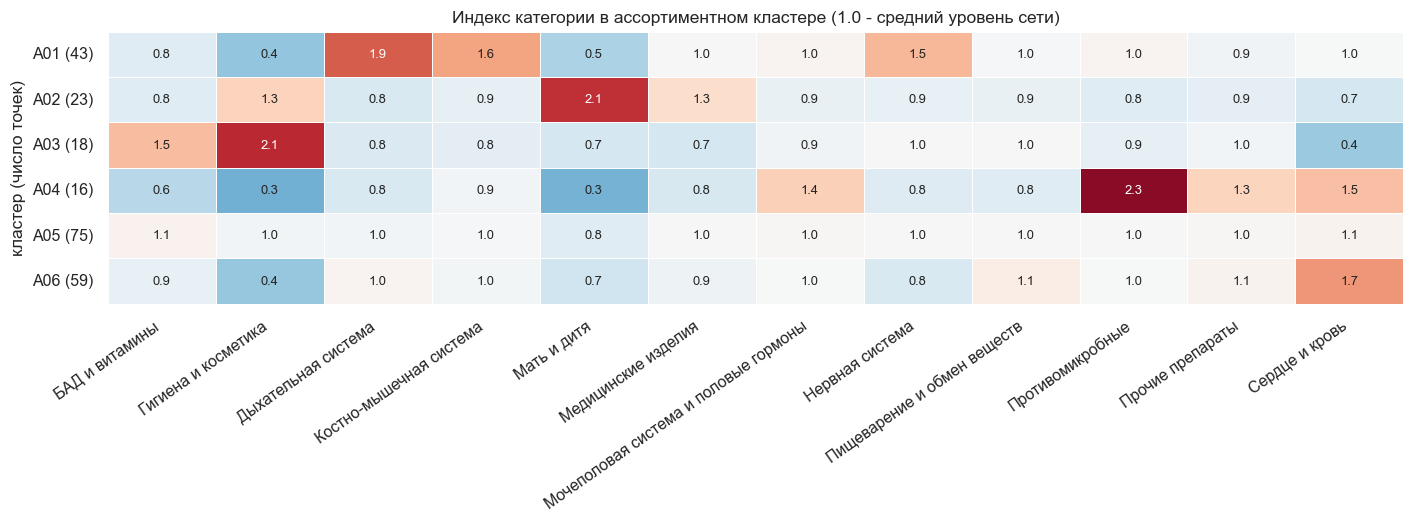

In [18]:
# индекс категории в кластере: доля в выручке кластера / доля в выручке сети (1.0 - как в среднем по сети)
network_share = df.groupby('category_group').Sum_Price.sum() / df.Sum_Price.sum()
cluster_share = assort.groupby(ID_groups).mean()
assort_index = cluster_share / network_share

plt.figure(figsize=(13, 0.45 * len(assort_index) + 2.2))
ax = sns.heatmap(assort_index, cmap='RdBu_r', center=1, vmin=0, vmax=2.5, cbar=False, linewidths=.5)
for (i, j), v in np.ndenumerate(assort_index.to_numpy()):
    ax.text(j + .5, i + .5, f'{v:.1f}', ha='center', va='center', fontsize=8.5,
            color='white' if abs(v - 1) > 0.9 else '#222')
plt.title('Индекс категории в ассортиментном кластере (1.0 - средний уровень сети)')
plt.xlabel(''); plt.ylabel('кластер (число точек)')
plt.yticks(np.arange(len(assort_index)) + .5, [f'{c} ({(ID_groups == c).sum()})' for c in assort_index.index], rotation=0)
plt.xticks(rotation=35, ha='right'); plt.tight_layout(); plt.show()

## 6. Итоговая сегментация - автоматически

В оригинале этот шаг был ручным: результаты трёх кластеризаций сводились в Excel, и сегментам давали названия
по пересечениям («Классическая аптека», «Аптека у дома», «ВИП-аптека»...). Здесь то же сведение
формализовано правилами:

- **размер**: кластеры по выручке и чекам упорядочиваются по средней выручке и получают названия по шкале
  «малые - небольшие - средние - большие - крупные» (при трёх кластерах - «малые, средние, крупные», при четырёх -
  «малые, средние, большие, крупные»);
- **цена**: так же по среднему индексу `доля high - доля low` - нижний кластер «эконом», верхний «премиум»,
  промежуточные «медиум». Названий столько же, сколько кластеров: если промежуточных кластеров два, они
  различаются как «медиум -» (ближе к эконому) и «медиум +» (ближе к премиуму), при нечётном числе в центре
  остаётся просто «медиум»;
- **ассортимент**: категории, у которых индекс в кластере не ниже 1.3, - это «уклон» сегмента (не больше двух);
  если таких нет - профиль универсальный.

Сегмент - сочетание трёх названий. Сочетания, в которые попало меньше 5 точек, для управления бесполезны:
такой сегмент вливается в ближайший крупный - по расстоянию между средними профилями точек (деньги, цена и
ассортимент стандартизуются, у каждого из трёх блоков одинаковый вес).

In [19]:
SHORT = {'Гигиена и косметика': 'косметика', 'Мать и дитя': 'мать и дитя', 'БАД и витамины': 'БАД',
         'Медицинские изделия': 'медизделия', 'Сердце и кровь': 'сердце и кровь', 'Оптика': 'оптика',
         'Противомикробные': 'антибиотики и противовирусные', 'Иммуномодуляторы и онкология': 'иммунология',
         'Гормоны системного действия': 'гормоны', 'Дыхательная система': 'простуда',
         'Нервная система': 'нервная система', 'Костно-мышечная система': 'опорно-двигательная',
         'Пищеварение и обмен веществ': 'ЖКТ и обмен веществ', 'Дерматология': 'дерматология',
         'Мочеполовая система и половые гормоны': 'урология и гинекология', 'Органы чувств': 'органы чувств'}
INDEX_THRESHOLD = 1.3
MIN_SEGMENT = 5          # сегмент меньше - вливается в ближайший крупный


def level_by_rank(cluster_values: pd.Series, low: str, mid: str, high: str) -> pd.Series:
    """Название уровня по месту кластера в порядке средних значений: крайние - low и high, промежуточные -
    mid с уточнением «-» (ниже середины) или «+» (выше середины); при нечётном числе центральный - просто mid."""
    rank = cluster_values.rank(method='first').astype(int) - 1
    k = len(rank)

    def name(i):
        if i == 0 and k > 1:
            return low
        if i == k - 1 and k > 1:
            return high
        pos = i / (k - 1) if k > 1 else 0.5
        return mid if abs(pos - 0.5) < 1e-9 or k == 3 else (f'{mid} -' if pos < 0.5 else f'{mid} +')
    return rank.map(name)


seg = stores[['TradePointCode', 'BrandName', 'BusinessUnit', 'Layout', 'Location', 'IsVip', 'IsDiscounter',
              'CurrentCategory']].join(size).join(price_profile).join(ID_groups.rename('ID_groups'))

log_rev = np.log(seg.Revenue)
# для размера - естественная шкала слов по числу кластеров
SIZE_NAMES = {1: ['Средние'], 2: ['Малые', 'Крупные'], 3: ['Малые', 'Средние', 'Крупные'],
              4: ['Малые', 'Средние', 'Большие', 'Крупные'], 5: ['Малые', 'Небольшие', 'Средние', 'Большие', 'Крупные']}
size_means = log_rev.groupby(seg.ID_size_rev_cheque).mean()
if len(size_means) in SIZE_NAMES:
    size_level = size_means.rank(method='first').astype(int).map(lambda i: SIZE_NAMES[len(size_means)][i - 1])
else:
    size_level = level_by_rank(size_means, 'Малые', 'Средние', 'Крупные')
pidx = seg.high - seg.low
price_level = level_by_rank(pidx.groupby(seg.ID_prices).mean(), 'эконом', 'медиум', 'премиум')


def profile_name(row):
    top = row[row >= INDEX_THRESHOLD].sort_values(ascending=False).head(2)
    return 'универсальный' if top.empty else ', '.join(SHORT.get(c, c.lower()) for c in top.index)


assort_profile = assort_index.apply(profile_name, axis=1)

seg['Размер'] = seg.ID_size_rev_cheque.map(size_level)
seg['Цена'] = seg.ID_prices.map(price_level)
seg['Ассортимент'] = seg.ID_groups.map(assort_profile)
seg['Сегмент'] = seg['Размер'] + ' ' + seg['Цена'] + ' · ' + seg['Ассортимент']

print('Размер:', dict(size_level.sort_index()))
print('Цена:  ', dict(price_level.sort_index()))
pd.DataFrame({'уклон ассортимента': assort_profile, 'точек': ID_groups.value_counts()}).sort_index()

Размер: {'В1': 'Малые', 'В2': 'Средние', 'В3': 'Большие', 'В4': 'Крупные'}
Цена:   {'Ц1': 'эконом', 'Ц2': 'медиум -', 'Ц3': 'медиум +', 'Ц4': 'премиум'}


,уклон ассортимента,точек
А01,"простуда, опорно-двигательная",43
А02,"мать и дитя, косметика",23
А03,"косметика, БАД",18
А04,"антибиотики и противовирусные, сердце и кровь",16
А05,универсальный,75
А06,сердце и кровь,59


In [20]:
# общее пространство профилей точки: деньги, цена, ассортимент - каждый блок стандартизован и весит одинаково
def block(X):
    Z = pd.DataFrame(StandardScaler().fit_transform(X), index=X.index)
    return Z / np.sqrt(Z.shape[1])


profile_space = pd.concat([block(X_money.loc[seg.index]), block(price_profile.loc[seg.index, ['low', 'medium', 'high']]),
                           block(X_assort.loc[seg.index])], axis=1)

seg['Сегмент до объединения'] = seg['Сегмент']
merges = []
while True:
    counts = seg['Сегмент'].value_counts()
    small = counts[counts < MIN_SEGMENT]
    if small.empty or len(counts) == 1:
        break
    src = small.index[-1]                                  # самый маленький
    centroids = profile_space.groupby(seg['Сегмент']).mean()
    big = counts[counts >= MIN_SEGMENT].index
    dist = ((centroids.loc[big] - centroids.loc[src]) ** 2).sum(axis=1) ** 0.5
    dst = dist.idxmin()
    merges.append({'из сегмента': src, 'точек': int(counts[src]), 'в сегмент': dst, 'расстояние': round(dist.min(), 2)})
    seg.loc[seg['Сегмент'] == src, 'Сегмент'] = dst

print(f"Сочетаний до объединения: {seg['Сегмент до объединения'].nunique()}, сегментов после: {seg['Сегмент'].nunique()}")
pd.DataFrame(merges)

Сочетаний до объединения: 26, сегментов после: 13


,из сегмента,точек,в сегмент,расстояние
0,Большие медиум - · универсальный,1,Большие медиум + · универсальный,0.78
1,"Малые медиум + · простуда, опорно-двигательная",1,"Средние медиум + · простуда, опорно-двигательная",1.40
2,Средние эконом · сердце и кровь,1,Большие эконом · сердце и кровь,0.99
3,Малые медиум - · антибиотики и противовирусные...,1,Малые медиум - · сердце и кровь,1.85
4,Малые медиум + · сердце и кровь,1,Малые медиум - · сердце и кровь,2.00
5,"Малые эконом · антибиотики и противовирусные, ...",1,Малые эконом · сердце и кровь,1.50
6,Малые медиум + · антибиотики и противовирусные...,1,Средние медиум + · антибиотики и противовирусн...,1.71
7,Крупные эконом · сердце и кровь,1,Большие эконом · сердце и кровь,1.13
8,"Большие медиум + · простуда, опорно-двигательная",2,"Большие медиум - · простуда, опорно-двигательная",0.68
9,Средние медиум - · универсальный,2,Средние медиум + · универсальный,0.69


In [21]:
summary = seg.groupby('Сегмент').agg(
    точек=('TradePointCode', 'size'), площадь_м2=('TradeSquare', 'median'), выручка=('Revenue', 'median'),
    средний_чек=('mean_purch', 'median'), доля_high=('high', 'mean'), доля_low=('low', 'mean'),
).sort_values('выручка', ascending=False)
summary.style.format({'площадь_м2': '{:.0f}', 'выручка': '{:,.0f}', 'средний_чек': '{:,.0f}',
                      'доля_high': '{:.0%}', 'доля_low': '{:.0%}'}).background_gradient(subset=['выручка'], cmap='Blues')

,точек,площадь_м2,выручка,средний_чек,доля_high,доля_low
Сегмент,,,,,,
Крупные медиум + · универсальный,20,174,"6,809,546","2,965",56%,11%
"Крупные медиум + · мать и дитя, косметика",13,114,"5,255,124","2,338",58%,10%
"Большие медиум + · мать и дитя, косметика",10,125,"4,038,410","2,436",59%,10%
"Большие премиум · косметика, БАД",18,82,"3,490,773","4,094",71%,5%
Большие медиум + · универсальный,39,99,"2,911,002","2,296",54%,12%
Средние медиум + · универсальный,14,82,"1,962,697","2,296",54%,12%
Большие эконом · сердце и кровь,31,70,"1,870,462","1,124",34%,27%
"Большие медиум - · простуда, опорно-двигательная",13,52,"1,795,014","1,546",50%,15%
"Средние медиум + · антибиотики и противовирусные, сердце и кровь",14,30,"1,418,834","2,327",56%,10%


### Пересечения разбиений

Насколько три взгляда на точку согласуются друг с другом. Если бы ценовой кластер почти однозначно определялся
размером, отдельная ценовая кластеризация не несла бы новой информации.

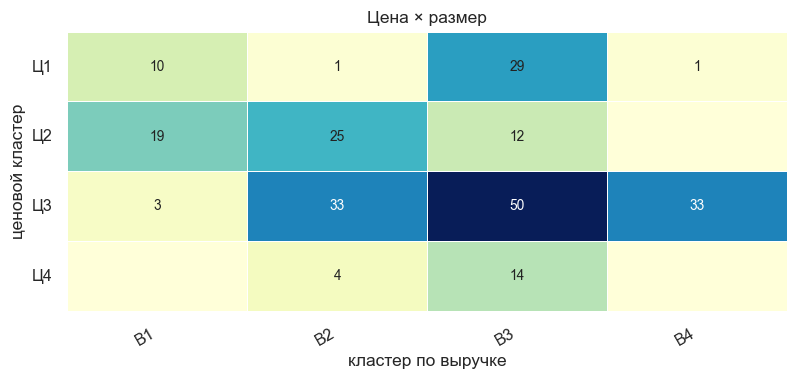

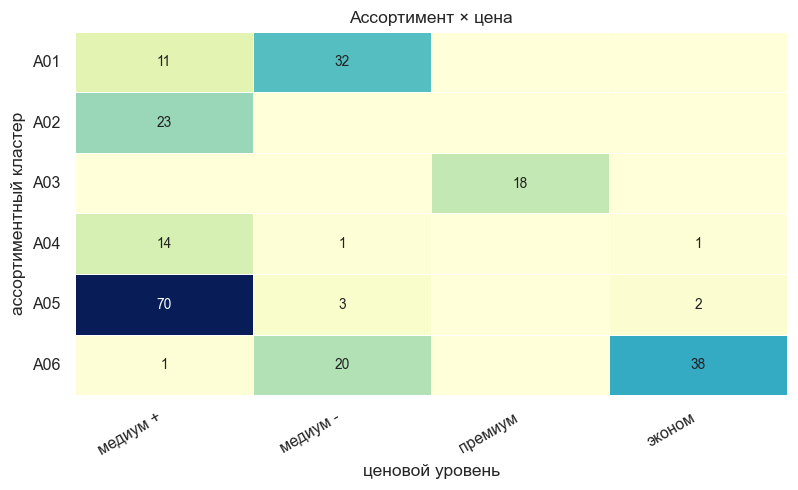

In [22]:
plot_crosstab(seg.ID_prices.rename('ценовой кластер'), seg.ID_size_rev_cheque.rename('кластер по выручке'),
              'Цена × размер')
plot_crosstab(seg.ID_groups.rename('ассортиментный кластер'), seg['Цена'].rename('ценовой уровень'),
              'Ассортимент × цена')

### Проверка сегментов на известных характеристиках точек

Правдоподобна ли сегментация: сходится ли она с тем, что про точку и так известно - бренд сети, локация,
формат выкладки (ОФТ - открытая форма торговли, ЗФТ - закрытая). Эти признаки в кластеризации не участвовали.

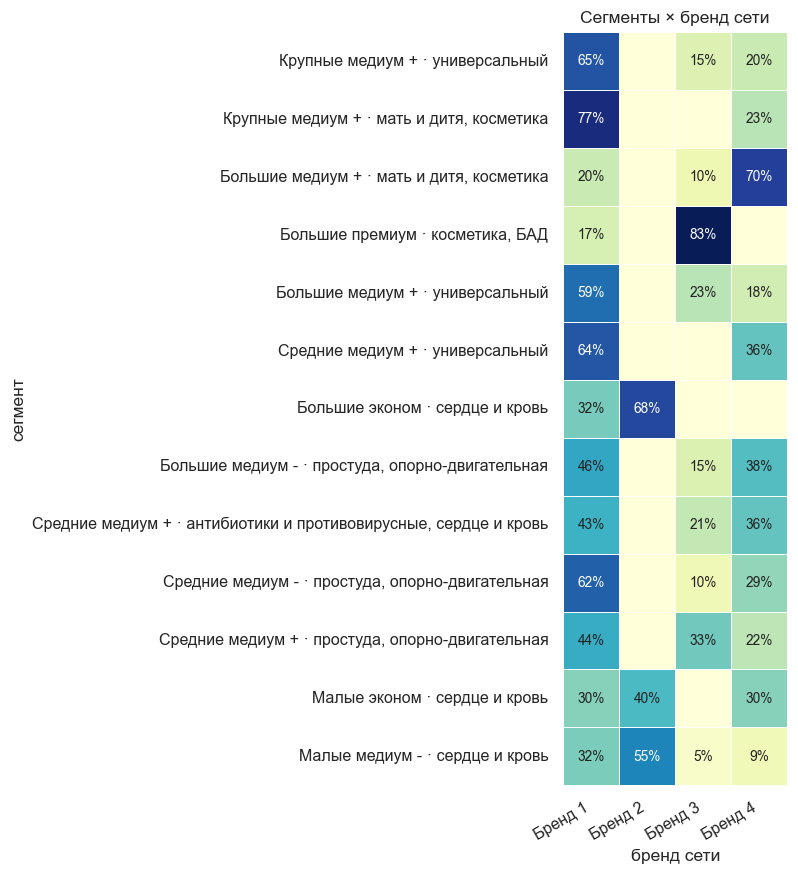

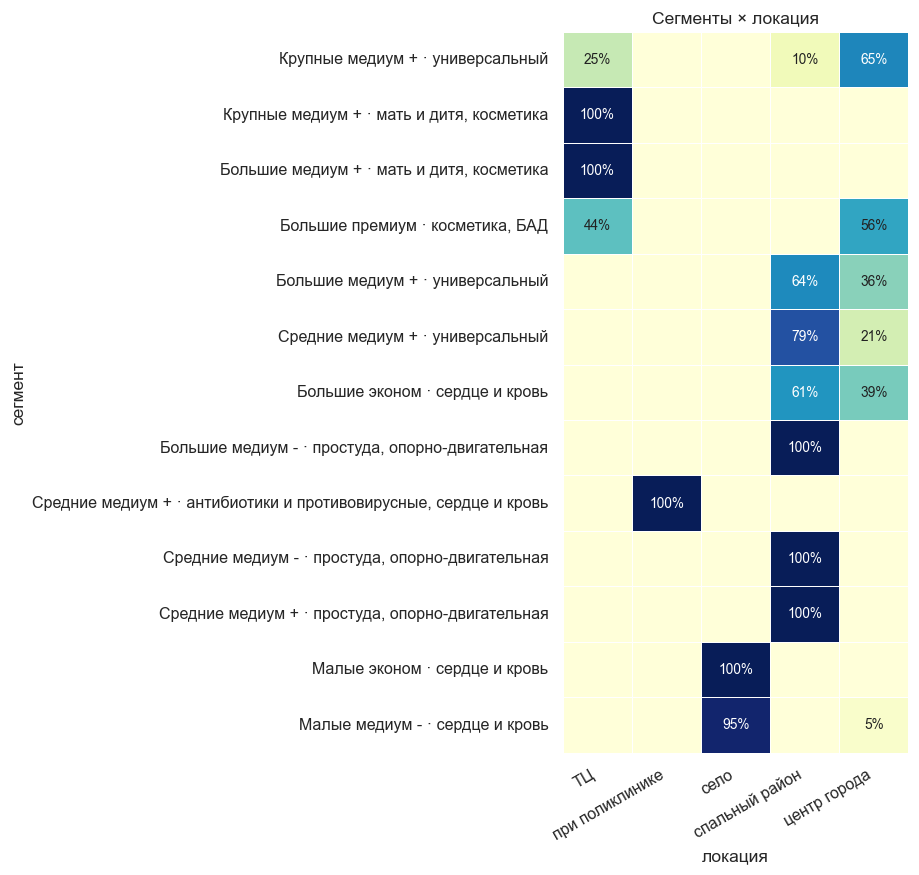

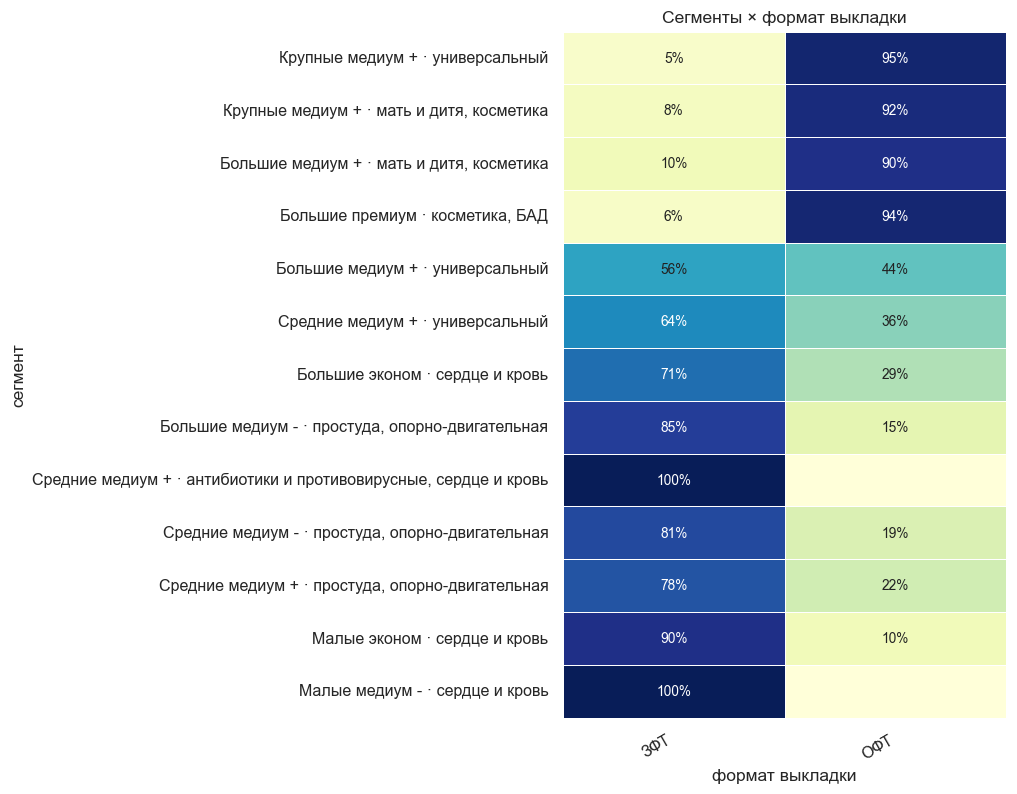

In [23]:
order = summary.index
for col, title in [('BrandName', 'Бренд сети'), ('Location', 'Локация'), ('Layout', 'Формат выкладки')]:
    plot_crosstab(seg['Сегмент'].rename('сегмент').astype(pd.CategoricalDtype(order, ordered=True)),
                  seg[col].rename(title.lower()), f'Сегменты × {title.lower()}', normalize=True)

### Проверка на заложенной структуре

Возможна только на синтетике: генератор данных заложил в каждую точку скрытый архетип (центральная аптека,
аптека у дома, дискаунтер и т.д.), а алгоритм его не видел. Если кластеризация работает, сегменты должны в
основном совпадать с архетипами. Мера совпадения - скорректированный индекс Рэнда (ARI): 0 - случайное
разбиение, 1 - полное совпадение.

ARI   ID_size_rev_cheque: 0.27
ARI            ID_prices: 0.33
ARI            ID_groups: 0.72
ARI              Сегмент: 0.69


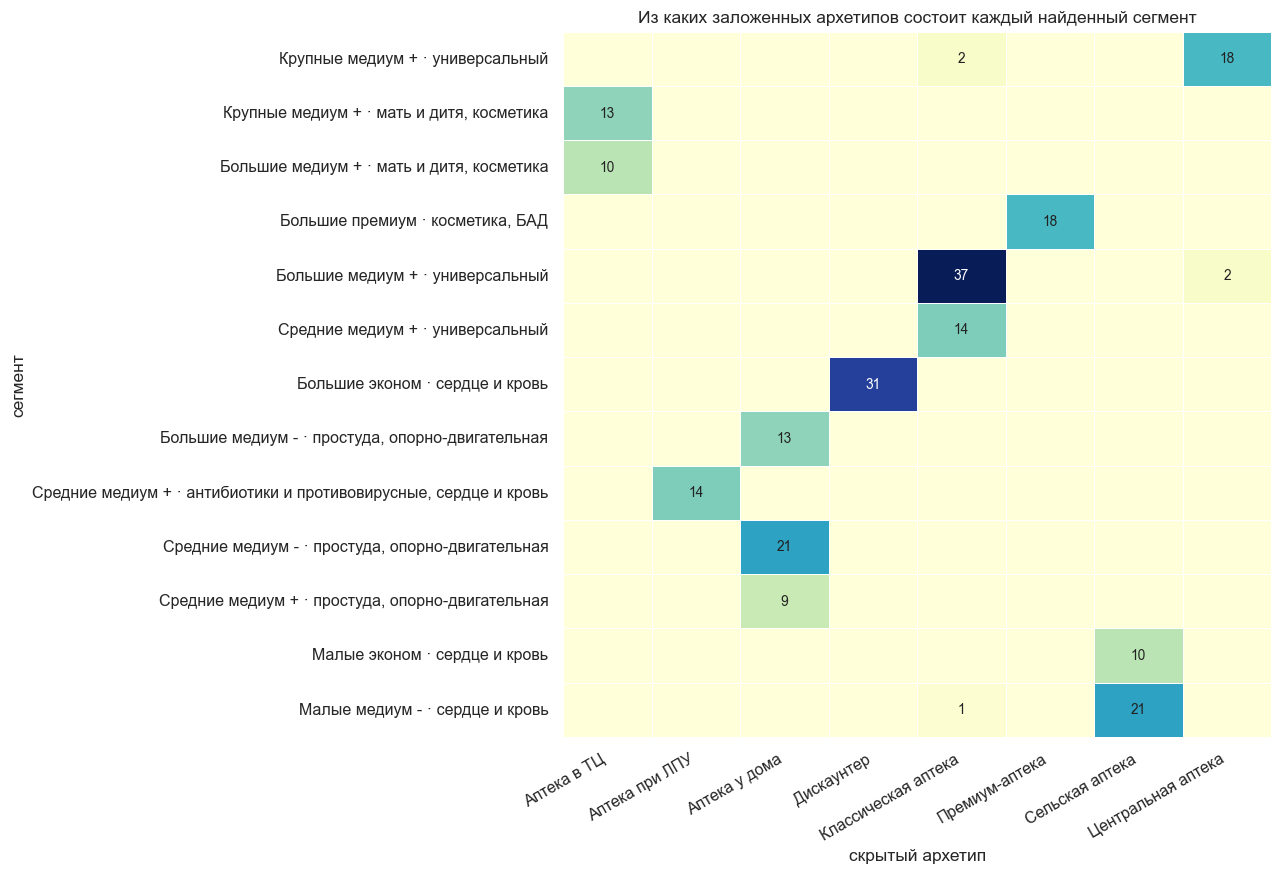

In [24]:
truth = query("SELECT TradePointId, archetype FROM pharmacy.store_archetypes").set_index('TradePointId').archetype
seg['Архетип (скрытый)'] = truth.reindex(seg.index)
for col in ['ID_size_rev_cheque', 'ID_prices', 'ID_groups', 'Сегмент']:
    print(f'ARI {col:>20}: {adjusted_rand_score(seg["Архетип (скрытый)"], seg[col]):.2f}')

plot_crosstab(seg['Сегмент'].rename('сегмент').astype(pd.CategoricalDtype(order, ordered=True)),
              seg['Архетип (скрытый)'].rename('скрытый архетип'),
              'Из каких заложенных архетипов состоит каждый найденный сегмент')

## 7. Сохранение результата

Сегменты точек и ценовые уровни товаров записываются в схему `results` той же базы - их использует следующий проект
([скоринг и выбор ассортиментной матрицы](../Скоринг%20и%20выбор%20ассортиментной%20матрицы)).

In [25]:
def save(frame: pd.DataFrame, table: str):
    con.execute('CREATE SCHEMA IF NOT EXISTS results')
    con.register('tmp_df', frame)
    con.execute(f'CREATE OR REPLACE TABLE results.{table} AS SELECT * FROM tmp_df')
    con.unregister('tmp_df')


out = seg.reset_index()[['TradePointId', 'TradePointCode', 'ID_size_square', 'ID_size_rev_cheque', 'ID_prices',
                         'ID_groups', 'Размер', 'Цена', 'Ассортимент', 'Сегмент', 'Сегмент до объединения', 'TradeSquare', 'Revenue',
                         'ChequeCount', 'mean_purch', 'low', 'medium', 'high']]
out.columns = ['TradePointId', 'TradePointCode', 'size_square_cluster', 'size_money_cluster', 'price_cluster',
               'assortment_cluster', 'size_level', 'price_level', 'assortment_profile', 'segment', 'segment_raw', 'trade_square',
               'revenue', 'cheque_count', 'mean_cheque', 'share_low', 'share_medium', 'share_high']
save(out, 'store_segments')
save(pd.DataFrame(merges, columns=['из сегмента', 'точек', 'в сегмент', 'расстояние'])
     .rename(columns={'из сегмента': 'from_segment', 'точек': 'n_stores', 'в сегмент': 'to_segment', 'расстояние': 'distance'}),
     'segment_merges')

# агрегаты для графиков на сайте: индекс категорий в ассортиментных кластерах и качество кластеризации
assort_long = assort_index.stack().rename('index').reset_index()
assort_long.columns = ['cluster', 'category', 'index']
assort_long['profile'] = assort_long.cluster.map(assort_profile)
assort_long['n_stores'] = assort_long.cluster.map(ID_groups.value_counts())
save(assort_long, 'clustering_assort_index')
quality_cols = ['ID_size_rev_cheque', 'ID_prices', 'ID_groups', 'Сегмент']
save(pd.DataFrame({'metric': quality_cols,
                   'ari': [adjusted_rand_score(seg['Архетип (скрытый)'], seg[c]) for c in quality_cols]}),
     'clustering_quality')

tiers = price.reset_index()[['apCode', 'subcategory', 'pack_group', 'mean_package', 'price_tier']]
save(tiers, 'product_price_tiers')
save(pd.DataFrame(K_DIAGNOSTICS), 'clustering_k_selection')
print(f'results.store_segments: {len(out)} точек, {out.segment.nunique()} сегментов')
print(f'results.product_price_tiers: {len(tiers):,} товаров')
con.close()

results.store_segments: 234 точек, 13 сегментов
results.product_price_tiers: 2,956 товаров


## Отличия от оригинального расчёта

- **6 ноутбуков → 1.** Отбор точек, три кластеризации, пересечения и итоговая сегментация идут одним прогоном.
- **Маленькие сочетания уровней вливаются в ближайший сегмент** (в оригинале их сводили вручную).
- **Нет ручных шагов.** Число кластеров выбирается автоматически по тому же «локтю» дендрограммы, который в
  оригинале смотрели глазами; сведение трёх разбиений и названия сегментов строятся правилами (раздел 6),
  а не вручную в Excel.
- **Цена сравнивается по пачке внутри категории фасовки** (в оригинале было два варианта: цена упаковки и
  цена за дозу из отдельного справочника фасовок). Пересчёт на дозу делал большие пачки искусственно
  «дешёвыми», а покупатель платит за пачку; сравнение с пачками похожего объёма убирает оба перекоса.
- **Исключённый производитель** оригинала (со своей моделью ценообразования) заменён на исключение товаров СТМ.
- **Мелкие категории (меньше 2% выручки сети) объединяются** перед ассортиментной кластеризацией.
- **Выручка и чеки кластеризуются в логарифмах** - на синтетике распределения сильно скошены.
- **Из ассортиментной части оставлен финальный вариант** (совместная кластеризация по всему вектору долей);
  промежуточные поочерёдные разбиения по отдельным категориям не показаны.
- **Добавлена проверка на заложенной структуре** (ARI) - на реальных данных такой «правильный ответ» недоступен.